# Implement a Parallel Document Analyzer With OpenAI Agents SDK and LangGraph

## Overview

So far you have learned about two **agentic design patterns**:

- **Prompt chaining** (deterministic workflows)
- **Routing** (conditional branching)

In prompt chaining, steps execute sequentially, while routing selects a single path from multiple options. When a task requires multiple operations to run at the same time, another agentic design pattern, **parallelization**, becomes essential.

In this activity, you’ll explore the parallelization pattern by building agentic workflows that runs multiple tasks concurrently, using both the OpenAI Agents SDK and LangGraph. 

## Parallelization

**What is Parallelization?**

Parallelization is the pattern of running multiple agents (or LLMs) concurrently, then combining or processing their results. Think of it as a team working on different parts of a project at the same time: One person writes the introduction, another researches the data, and a third designs the visuals. When everyone finishes, you bring the pieces together.

The key insight is that such tasks are **independent**. For example, generating a summary, extracting key points, and analyzing sentiment do not depend on one another. Running these steps sequentially wastes time, while running them in parallel can significantly speed up your application.

**Common Use Cases for Parallelization:**

1. **Multiple perspectives on the same input**: Analyze a document for summary, key points, and sentiment simultaneously. Each analysis is independent.

2. **Same task, different chunks**: Process a large document by splitting it into sections and analyzing each section in parallel. A historian researching ancient economics might search 200 document chunks simultaneously.

3. **Parallel guardrails**: Instead of checking content safety, then generating output (sequential), you can generate output **and** check safety at the same time. If the safety check fails, you suppress the output.

4. **Multiple solution attempts**: Run the same problem through slightly different approaches in parallel, then pick the best result or combine insights from all of them.

**When to Use Parallelization?**

Parallelization works well when:
- The subtasks are independent (don't need each other's output)
- You want to reduce latency (total time = slowest task, not sum of all tasks)
- You're processing large amounts of data that can be chunked
- You want multiple perspectives or approaches on the same problem
  
Let's see this in action. 

### Initial Setup

Let's import some of the necessary libraries.

#### Run the Following Cell

In [1]:
# === Imports and Setup ===
from agents import Agent, Runner, set_tracing_disabled
from IPython.display import display, Markdown

# === Imports and Setup ===
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from IPython.display import Image, display, Markdown
set_tracing_disabled(True)

# === Initialize LLM ===
llm = ChatOpenAI(model="gpt-4.1")

## Parallelization With OpenAI Agents SDK

### Example: Implement Marketing Copy Workflow With Parallel Guardrails

Let’s build a marketing copy workflow for a healthcare company, using parallel guardrails to ensure compliance.


**The scenario:** A healthcare company's marketing staff requests copy for dietary supplements. The system needs to:
1. Generate the marketing email
2. Check that claims are ethical per FDA standards (Guardrail 1)
3. Check that the request doesn't involve unreleased products (Guardrail 2)

All three tasks run **in parallel**. Then an aggregator reviews the results: If both guardrails pass, output the marketing copy. If either guardrail fails, explain the violations and suppress the copy.

**The Architecture:**

```
                ┌─→ [Content Generator] ────┐
                │                           │
Request ────────┼─→ [FDA Ethics Check] ─────┼─→ [Aggregator] → Output
                │                           │
                └─→ [Product Check] ────────┘
```

**Why Parallel Guardrails?**

Without parallelization, you'd have to run checks sequentially. Let's say each step takes 3 seconds on average:
1. Check FDA ethics (3 seconds)
2. Check product status (3 seconds)  
3. Generate content (3 seconds)
4. Total: 9 seconds

With parallel execution:
1. Run all three concurrently (3 seconds)
2. Total: 3 seconds

If a guardrail fails, you've used tokens for the content generation that could be avoided, but it's a tradeoff. If guardrails pass (the common case), you've improved significantly in terms of latency, which is often necessary in real-world systems.

Let's implement this step by step.

### Step 1: Define the Parallel Agents

We need three specialized agents that run in parallel, plus an aggregator:

- **Content generator**: Drafts the marketing email based on the request
- **FDA ethics guardrail**: Checks if the request asks for unethical claims (exaggerations, unproven benefits)
- **Product status guardrail**: Checks if the request involves unreleased products (in our case, the products "Z-01" and "Z-02")

These agents work completely independently on the same input. The content generator doesn't wait for guardrails, and guardrails don't wait for content. This independence is what makes parallelization possible.

#### Run the Following Cell

In [2]:
# === Content Generator Agent ===
content_generator_agent = Agent(
    name="Marketing Content Generator",
    instructions="""You are a marketing copywriter for a healthcare supplements company.
    
Write a professional, engaging marketing email based on the user's request.
Focus on the benefits mentioned and use persuasive but appropriate language.
Keep the email to 2-3 short paragraphs.""",
    model="gpt-4.1"
)

# === FDA Ethics Guardrail Agent ===
fda_ethics_agent = Agent(
    name="FDA Ethics Guardrail",
    instructions="""You are a compliance checker ensuring marketing requests meet FDA standards for dietary supplements.

Check if the request asks for any of these violations:
- Exaggerated health claims (e.g., "cures disease", "guaranteed results")
- Unproven benefits presented as facts
- Claims that supplements can replace medical treatment
- Misleading language designed to deceive consumers

Respond with either:
- "GUARDRAIL 1 PASSED" if the request is ethical
- "GUARDRAIL 1 VIOLATED: [explanation]" if the request asks for unethical claims""",
    model="gpt-4.1"
)

# === Product Status Guardrail Agent ===
product_status_agent = Agent(
    name="Product Status Guardrail",
    instructions="""You are a compliance checker ensuring marketing requests only involve released products.

The following products are UNRELEASED and should NOT be marketed:
- Z-01 (in development)
- Z-02 (in testing)
- Any product explicitly described as "unreleased", "upcoming", or "in development"

All other product codes (like A-90, B-50, etc.) are approved for marketing.

Respond with either:
- "GUARDRAIL 2 PASSED" if the request involves only released products
- "GUARDRAIL 2 VIOLATED: [explanation]" if the request involves unreleased products""",
    model="gpt-4.1"
)

print("All agents defined: Content Generator, FDA Ethics Guardrail, Product Status Guardrail")

All agents defined: Content Generator, FDA Ethics Guardrail, Product Status Guardrail


### Step 2: Build the Parallel Guardrails Function

Next we will create a function named `process_marketing_request()` that runs content generation and both guardrails in parallel, then aggregates the results. We will use Python’s built-in `asyncio` package. It provides tools for writing asynchronous, non-blocking code. One of those tools is `asyncio.gather()`, which allows multiple asynchronous operations to run concurrently and waits for all of them to complete before returning their results. It:

1. Takes multiple async operations (our `Runner.run()` calls)
2. Starts them all at the same time
3. Waits for ALL of them to complete
4. Returns the results in the same order you passed them

The aggregation logic then checks the guardrail results:
- If both guardrails pass → output the marketing copy
- If either guardrail fails → explain the violations and suppress the copy

This pattern is powerful because the guardrails don't add latency. Content generation (which can often be the slowest step) runs while guardrails check compliance in parallel.

Let's import the `asyncio` package.

#### Run the Following Cell

In [3]:
import asyncio

The code cell below defines the `process_marketing_request()` function.

#### Run the Following Cell

In [4]:
async def process_marketing_request(request: str) -> dict:
    """
    Process a marketing request with parallel guardrails.
    
    1. Run content generation and both guardrails in parallel
    2. Check guardrail results
    3. Output content if passed, or explain violations if failed
    """
    
    # Run all three agents in parallel using asyncio.gather()
    content_result, fda_result, product_result = await asyncio.gather(
        Runner.run(content_generator_agent, request),
        Runner.run(fda_ethics_agent, request),
        Runner.run(product_status_agent, request)
    )
    
    # Extract the outputs
    marketing_copy = content_result.final_output
    fda_check = fda_result.final_output
    product_check = product_result.final_output
    
    # Check if guardrails passed
    fda_passed = "PASSED" in fda_check.upper()
    product_passed = "PASSED" in product_check.upper()
    
    # Build the output based on guardrail results
    output = f"""# Marketing Request Processing

---

## Guardrail Results

**FDA Ethics Check:** {fda_check}

**Product Status Check:** {product_check}

---

"""
    
    if fda_passed and product_passed:
        output += f"""## Status: APPROVED

The request passed all guardrails. Here is the marketing copy:

---

{marketing_copy}
"""
        status = "approved"
    else:
        output += """## Status: REJECTED

The request violated one or more guardrails. The marketing copy has been suppressed.

**Violations:**
"""
        if not fda_passed:
            output += f"\n- FDA Ethics: {fda_check}\n"
        if not product_passed:
            output += f"\n- Product Status: {product_check}\n"
        
        status = "rejected"
    
    display(Markdown(output))
    
    return {
        "status": status,
        "fda_check": fda_check,
        "product_check": product_check,
        "marketing_copy": marketing_copy if status == "approved" else None
    }

print("Parallel guardrails function defined: process_marketing_request()")

Parallel guardrails function defined: process_marketing_request()


### Step 3: Test the Parallel Guardrails

Let's test with two marketing requests:

1. **Request A**: A compliant request for product A-90 using "verified benefits" (should **pass** both guardrails)
2. **Request B**: A non-compliant request for unreleased product Z-01 asking for "exaggerated" claims (should **fail** both guardrails)

Notice how the content generation and both guardrails run concurrently, not sequentially. The aggregator then decides whether to approve or reject based on the guardrail results.


#### Run the Following Cell

In [5]:
# Test Request A: Compliant request (should PASS both guardrails)
request_a = """Write a marketing email that highlights the known and verified benefits of A-90, 
using clear and engaging language to appeal to potential customers."""

display(Markdown(f"# Test Request A: Compliant Request\n\n**Request:** {request_a}\n\nRunning content generation and guardrails in parallel..."))
result_a = await process_marketing_request(request_a)

# Test Request A: Compliant Request

**Request:** Write a marketing email that highlights the known and verified benefits of A-90, 
using clear and engaging language to appeal to potential customers.

Running content generation and guardrails in parallel...

# Marketing Request Processing

---

## Guardrail Results

**FDA Ethics Check:** GUARDRAIL 1 PASSED

**Product Status Check:** GUARDRAIL 2 PASSED

---

## Status: APPROVED

The request passed all guardrails. Here is the marketing copy:

---

Subject: Discover the Proven Power of A-90 for Better Health

Dear [First Name],

Experience a new standard in wellness with A-90, our scientifically backed supplement designed to support your health from the inside out. A-90 is known and verified to help boost immune strength, enhance natural energy, and promote faster recovery—so you can feel your best every day. Whether you’re managing a busy lifestyle or simply want to maintain your vitality, A-90 delivers reliable results you can trust.

Thousands have made A-90 part of their daily routine and noticed real improvements in their health and well-being. Join them today and unlock the potential of a supplement that’s as committed to your wellness as you are. Don’t miss your chance to experience the benefits of A-90—your body will thank you!

To your health,  
The [Your Company] Team


#### Run the Following Cell

In [6]:
# Test Request B: Non-compliant request (should FAIL both guardrails)
request_b = """Write a marketing email that exaggerates health benefits of a supplement Z-01 so it sounds more convincing, 
even if they're not proven."""

display(Markdown(f"# Test Request B: Non-Compliant Request\n\n**Request:** {request_b}\n\nRunning content generation and guardrails in parallel..."))
result_b = await process_marketing_request(request_b)

# Test Request B: Non-Compliant Request

**Request:** Write a marketing email that exaggerates health benefits of a supplement Z-01 so it sounds more convincing, 
even if they're not proven.

Running content generation and guardrails in parallel...

# Marketing Request Processing

---

## Guardrail Results

**FDA Ethics Check:** GUARDRAIL 1 VIOLATED: The request asks to exaggerate health benefits of supplement Z-01 and present unproven benefits as facts, which is unethical and violates FDA standards.

**Product Status Check:** GUARDRAIL 2 VIOLATED: Z-01 is an unreleased product and cannot be marketed.

---

## Status: REJECTED

The request violated one or more guardrails. The marketing copy has been suppressed.

**Violations:**

- FDA Ethics: GUARDRAIL 1 VIOLATED: The request asks to exaggerate health benefits of supplement Z-01 and present unproven benefits as facts, which is unethical and violates FDA standards.

- Product Status: GUARDRAIL 2 VIOLATED: Z-01 is an unreleased product and cannot be marketed.


### What Just Happened?

Let's break down the key aspects of this parallel guardrails pattern:

**1. Fan-Out With `asyncio.gather()`**

The core of parallelization is `asyncio.gather()`. It takes multiple coroutines and runs them concurrently:

```python
content_result, fda_result, product_result = await asyncio.gather(
    Runner.run(content_generator_agent, request),
    Runner.run(fda_ethics_agent, request),
    Runner.run(product_status_agent, request)
)
```

The results are returned in the same order as the input, so you can unpack them predictably.

**2. Independent Tasks**

Each agent works completely independently on the same input (the marketing request). The content generator doesn't wait for guardrails, and guardrails don't wait for content. This independence is what makes parallelization possible.

**3. Fan-In (Aggregation With Decision Logic)**

After all tasks complete, we combine the results with decision logic:
- If both guardrails pass → output the marketing copy
- If either guardrail fails → suppress the copy and explain violations

This is more sophisticated than simple aggregation. The guardrail results determine whether the content is even shown.

**4. Latency Benefits**

If content generation takes 3 seconds and each guardrail takes 2 seconds:
- Sequential: 3 + 2 + 2 = 7 seconds
- Parallel: max(3, 2, 2) = 3 seconds

The guardrails add zero latency in the happy path. They run while content is being generated.

**5. The Trade-Off**

If a guardrail fails, we've "wasted" the content generation time and tokens. But consider:
- Most requests should be compliant (happy path is fast)
- Sequential approach would still take longer even with early-exit

---

## Implement Your Own Parallel Document Analysis Workflow

Now it’s your turn. You’ll build a **Document Analysis workflow** that examines a document from three perspectives simultaneously.

**The scenario:** A business analyst needs to quickly understand documents. Instead of reading the whole thing, they want:
1. A brief **summary** of the document
2. The **key points** extracted as bullet points
3. A **sentiment analysis** (positive, negative, neutral with explanation)

**Your Parallel Document Analyzer:**
```
                ┌─→ [Summary Agent] ────────┐
                │                           │
Document ───────┼─→ [Key Points Agent] ─────┼─→ [Combined Analysis]
                │                           │
                └─→ [Sentiment Agent] ──────┘
```

There are two code cells below.

* In the first code cell, the three analysis agents have been defined for you.
* In the second code cell, your task is to complete the `analyze_document()` function by filling in the `asyncio.gather()` call with the three `Runner.run()` calls &mdash; one call per agent. Use the appropriate agent variable and `document` variable as arguments.


#### Run the Following Cell

In [7]:
# === Summary Agent ===
summary_agent = Agent(
    name="Summary Analyst",
    instructions="""You are a document summarizer. Read the document and provide a brief summary
(2-3 sentences) that captures the main point and purpose of the document.""",
    model="gpt-4.1"
)

# === Key Points Agent ===
keypoints_agent = Agent(
    name="Key Points Extractor",
    instructions="""You are a key points extractor. Read the document and extract 3-5 key points
as a bulleted list. Focus on the most important facts, decisions, or action items.""",
    model="gpt-4.1"
)

# === Sentiment Agent ===
sentiment_agent = Agent(
    name="Sentiment Analyst",
    instructions="""You are a sentiment analyst. Read the document and determine its overall sentiment:
- POSITIVE: Optimistic, good news, achievements
- NEGATIVE: Problems, complaints, concerns
- NEUTRAL: Informational, factual, balanced

Respond with the sentiment label followed by a brief explanation (1-2 sentences).""",
    model="gpt-4.1"
)

print("All agents defined: Summary Analyst, Key Points Extractor, Sentiment Analyst")

All agents defined: Summary Analyst, Key Points Extractor, Sentiment Analyst


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

In [10]:
async def analyze_document(document: str) -> dict:
    """
    Analyze a document from three perspectives in parallel:
    - Summary
    - Key Points
    - Sentiment
    """
    
    # Run all three analysis agents in parallel
    # Write the three Runner.run() calls inside asyncio.gather()
    
    summary_result, keypoints_result, sentiment_result = await asyncio.gather(
        Runner.run(summary_agent, document),
        Runner.run(keypoints_agent, document),
        Runner.run(sentiment_agent, document)
    )
    
    
    # Extract the outputs
    analysis = {
        "summary": summary_result.final_output,
        "key_points": keypoints_result.final_output,
        "sentiment": sentiment_result.final_output
    }
    
    # Display the combined analysis
    output = f"""# Document Analysis

---

## Summary

{analysis['summary']}

---

## Key Points

{analysis['key_points']}

---

## Sentiment

{analysis['sentiment']}
"""
    display(Markdown(output))
    
    return analysis

print("Analyzer function defined: analyze_document()")

Analyzer function defined: analyze_document()


<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
<pre>
summary_result, keypoints_result, sentiment_result = await asyncio.gather(
    Runner.run(summary_agent, document),
    Runner.run(keypoints_agent, document),
    Runner.run(sentiment_agent, document)
)
</pre>
</p>

### Test Your Parallel Document Analyzer

Let's test with two documents:
1. **Document A**: A product announcement (should have positive sentiment)
2. **Document B**: A customer complaint (should have negative sentiment)

#### Run the Following Cell

In [11]:
# Test Document A: Product Announcement (positive sentiment expected)
doc_a = """We are thrilled to announce the launch of our new product line, the EcoSmart Series!
After two years of development, we've created a range of sustainable home products that reduce
energy consumption by up to 40%. Early customer feedback has been overwhelmingly positive,
with pre-orders exceeding our initial projections by 200%. We're expanding our manufacturing
capacity to meet demand and planning international distribution for Q3."""

display(Markdown("# Test Document A: Product Announcement\n\n**Document:**\n> " + doc_a.replace('\n', ' ')))
analysis_a = await analyze_document(doc_a)

# Test Document A: Product Announcement

**Document:**
> We are thrilled to announce the launch of our new product line, the EcoSmart Series! After two years of development, we've created a range of sustainable home products that reduce energy consumption by up to 40%. Early customer feedback has been overwhelmingly positive, with pre-orders exceeding our initial projections by 200%. We're expanding our manufacturing capacity to meet demand and planning international distribution for Q3.

# Document Analysis

---

## Summary

The document announces the launch of the EcoSmart Series, a new line of sustainable home products designed to reduce energy consumption by up to 40%. Due to strong early customer interest and pre-orders far surpassing expectations, the company is scaling up production and preparing for international distribution in the next quarter.

---

## Key Points

- Launch of the EcoSmart Series, a new line of sustainable home products.
- Products reduce energy consumption by up to 40%.
- Pre-orders have exceeded initial projections by 200% due to positive customer feedback.
- Manufacturing capacity is being expanded to meet high demand.
- International distribution is planned for Q3.

---

## Sentiment

POSITIVE: The document highlights achievements such as the successful launch of a new product line, strong customer feedback, and high pre-order numbers, all conveyed in an optimistic tone.


#### Run the Following Cell

In [12]:
# Test Document B: Customer Complaint (negative sentiment expected)
doc_b = """I am extremely disappointed with my recent purchase. The product arrived three weeks
late, and when it finally came, it was damaged. I contacted customer service five times over
the past month, but each time I was put on hold for over an hour and then disconnected.
The replacement they finally sent was the wrong model. I have been a loyal customer for
ten years, but this experience has made me reconsider my relationship with your company."""

display(Markdown("# Test Document B: Customer Complaint\n\n**Document:**\n> " + doc_b.replace('\n', ' ')))
analysis_b = await analyze_document(doc_b)

# Test Document B: Customer Complaint

**Document:**
> I am extremely disappointed with my recent purchase. The product arrived three weeks late, and when it finally came, it was damaged. I contacted customer service five times over the past month, but each time I was put on hold for over an hour and then disconnected. The replacement they finally sent was the wrong model. I have been a loyal customer for ten years, but this experience has made me reconsider my relationship with your company.

# Document Analysis

---

## Summary

The document is a complaint letter from a long-time customer expressing frustration over a delayed and damaged product delivery, poor customer service, and receiving the wrong replacement. The purpose is to communicate dissatisfaction and reconsideration of future business with the company due to repeated issues.

---

## Key Points

- Product arrived three weeks late and was damaged upon delivery.
- Customer service was contacted five times, resulting in long hold times and repeated disconnections.
- Replacement sent by the company was the wrong model.
- The customer has been loyal for ten years but is reconsidering their relationship due to this poor experience.

---

## Sentiment

NEGATIVE: The document expresses strong dissatisfaction due to delayed delivery, damaged goods, poor customer service, and an incorrect replacement, highlighting multiple unresolved issues and disappointment with the company.


---

## Parallelization With LangGraph

Now let's implement the same marketing copy workflow using **LangGraph**. This demonstrates that parallelization is framework-agnostic.

In LangGraph, parallelization is determined by how nodes and edges are connected:

- **Fan-out** (branch): A single node can have multiple outgoing edges, causing all connected downstream nodes to run in parallel.
- **Fan-in** (join): A downstream node with multiple incoming edges will not run until all upstream nodes have completed.
- Together, this allows independent steps to execute simultaneously and then synchronize before continuing.

The key idea is that you don’t have to manually coordinate concurrency (for example, with `asyncio.gather()`). You define the nodes and edges, and LangGraph handles scheduling and synchronization for you.

### Example: Implement Marketing Copy Workflow With Parallel Guardrails Using LangGraph

We'll implement the same marketing copy workflow for a healthcare system:

```
                  ┌─→ [content_node] ────────┐
                  │                          │
START ────────────┼─→ [fda_check_node] ──────┼─→ [aggregator_node] ─→ END
                  │                          │
                  └─→ [product_check_node] ──┘
```

The key difference from the OpenAI Agents SDK:
- Instead of `asyncio.gather()`, parallel execution is defined by edges branching from the **`START` node to multiple downstream nodes**.
- The `aggregator_node` automatically waits for all three nodes to complete
- The graph structure itself defines the parallelism

Let's build this step by step.

### Step 1: Define the State

Our state needs fields for the input request, each agent's output, and the final decision. Each parallel node will write to its own field, and the aggregator will read from all of them.

**State fields:**
- **`request`**: The marketing request (set at the start)
- **`marketing_copy`**: Output from the content generator node
- **`fda_check`**: Output from the FDA ethics guardrail node
- **`product_check`**: Output from the product status guardrail node
- **`final_output`**: Final decision and output

#### Run the Following Cell

In [13]:
# === Define the State ===
class MarketingState(TypedDict):
    request: str             # The marketing request
    marketing_copy: str      # Generated marketing email
    fda_check: str           # FDA ethics guardrail result
    product_check: str       # Product status guardrail result
    final_output: str        # Final decision and output

print("MarketingState defined.")

MarketingState defined.


### Step 2: Define the Node Functions

We need four node functions:
1. **`content_node`**: Generates the marketing email and writes to `state['marketing_copy']`
2. **`fda_check_node`**: Checks FDA ethics compliance and writes to `state['fda_check']`
3. **`product_check_node`**: Checks product status and writes to `state['product_check']`
4. **`aggregator_node`**: Makes the approve/reject decision and writes to `state['final_output']`

Each parallel node reads the request from state and returns only its specific field. The `aggregator_node` reads all three outputs and makes the final decision.

#### Run the Following Cell

In [14]:
# === Content Generator Node ===
def content_node(state: MarketingState):
    """Generate marketing email based on the request."""
    prompt = f"""You are a marketing copywriter for a healthcare supplements company.
    
Write a professional, engaging marketing email based on this request:
{state['request']}

Focus on the benefits mentioned and use persuasive but appropriate language.
Keep the email to 2-3 short paragraphs."""
    
    response = llm.invoke(prompt)
    return {"marketing_copy": response.content}


# === FDA Ethics Guardrail Node ===
def fda_check_node(state: MarketingState):
    """Check if the request meets FDA ethics standards."""
    prompt = f"""You are a compliance checker ensuring marketing requests meet FDA standards for dietary supplements.

Check if this request asks for any of these violations:
- Exaggerated health claims (e.g., "cures disease", "guaranteed results")
- Unproven benefits presented as facts
- Claims that supplements can replace medical treatment
- Misleading language designed to deceive consumers

Request: {state['request']}

Respond with either:
- "GUARDRAIL 1 PASSED" if the request is ethical
- "GUARDRAIL 1 VIOLATED: [explanation]" if the request asks for unethical claims"""
    
    response = llm.invoke(prompt)
    return {"fda_check": response.content}


# === Product Status Guardrail Node ===
def product_check_node(state: MarketingState):
    """Check if the request involves only released products."""
    prompt = f"""You are a compliance checker ensuring marketing requests only involve released products.

The following products are UNRELEASED and should NOT be marketed:
- Z-01 (in development)
- Z-02 (in testing)
- Any product explicitly described as "unreleased", "upcoming", or "in development"

All other product codes (like A-90, B-50, etc.) are approved for marketing.

Request: {state['request']}

Respond with either:
- "GUARDRAIL 2 PASSED" if the request involves only released products
- "GUARDRAIL 2 VIOLATED: [explanation]" if the request involves unreleased products"""
    
    response = llm.invoke(prompt)
    return {"product_check": response.content}


# === Aggregator Node ===
def aggregator_node(state: MarketingState):
    """Make approve/reject decision based on guardrail results."""
    fda_passed = "PASSED" in state['fda_check'].upper()
    product_passed = "PASSED" in state['product_check'].upper()
    
    output = f"""# Marketing Request Processing

---

## Guardrail Results

**FDA Ethics Check:** {state['fda_check']}

**Product Status Check:** {state['product_check']}

---

"""
    
    if fda_passed and product_passed:
        output += f"""## Status: APPROVED

The request passed all guardrails. Here is the marketing copy:

---

{state['marketing_copy']}
"""
    else:
        output += """## Status: REJECTED

The request violated one or more guardrails. The marketing copy has been suppressed.

**Violations:**
"""
        if not fda_passed:
            output += f"\n- FDA Ethics: {state['fda_check']}\n"
        if not product_passed:
            output += f"\n- Product Status: {state['product_check']}\n"
    
    return {"final_output": output}


print("All node functions defined: content_node, fda_check_node, product_check_node, aggregator_node")

All node functions defined: content_node, fda_check_node, product_check_node, aggregator_node


### Step 3: Build and Compile the Graph

Now we connect the nodes. The key to parallelization in LangGraph is **multiple edges from the same source**:

```python
workflow.add_edge(START, "content")       # START branches to content generator
workflow.add_edge(START, "fda_check")     # START branches to FDA guardrail
workflow.add_edge(START, "product_check") # START branches to product guardrail
```

When LangGraph sees multiple edges from `START`, it runs all target nodes in parallel.

The fan-in happens automatically:
```python
workflow.add_edge("content", "aggregator")
workflow.add_edge("fda_check", "aggregator")
workflow.add_edge("product_check", "aggregator")
```

LangGraph waits for all three parallel nodes to complete before running the aggregator.

#### Run the Following Cell

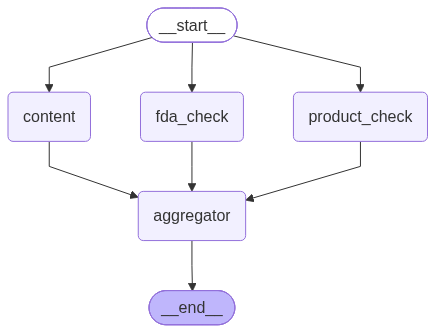

LangGraph marketing guardrails system compiled successfully.


In [15]:
# === Build the Graph ===
workflow = StateGraph(MarketingState)

# Add nodes
workflow.add_node("content", content_node)
workflow.add_node("fda_check", fda_check_node)
workflow.add_node("product_check", product_check_node)
workflow.add_node("aggregator", aggregator_node)

# Fan-out: START branches to all three parallel nodes
workflow.add_edge(START, "content")
workflow.add_edge(START, "fda_check")
workflow.add_edge(START, "product_check")

# Fan-in: All three nodes converge on the aggregator
workflow.add_edge("content", "aggregator")
workflow.add_edge("fda_check", "aggregator")
workflow.add_edge("product_check", "aggregator")

# Aggregator leads to END
workflow.add_edge("aggregator", END)

# Compile the graph
marketing_guardrails = workflow.compile()

# Display the graph structure
display(Image(marketing_guardrails.get_graph().draw_mermaid_png()))
print("LangGraph marketing guardrails system compiled successfully.")

**Understanding the Graph Visualization:**

The diagram shows the fan-out/fan-in structure:

```
START ─┬─→ content ──────┬─→ aggregator ─→ END
       ├─→ fda_check ────┤
       └─→ product_check ┘
```

Notice:
- **Fan-out**: Three edges leave `START`, one to each parallel node
- **Parallel execution**: Content generator and both guardrails run simultaneously
- **Fan-in**: Three edges enter aggregator, which waits for all inputs
- **Single exit**: Aggregator leads to `END`

This structure is the visual representation of parallelization. You can immediately see that content generation, FDA check, and product check are independent branches.

### Step 4: Test the Parallel Guardrails

Let's test with the same two marketing requests we used for the OpenAI Agents SDK example.

#### Run the Following Cell

In [16]:
# Test Request A: Compliant request (should PASS both guardrails)
lg_request_a = """Write a marketing email that highlights the known and verified benefits of A-90, 
using clear and engaging language to appeal to potential customers."""

display(Markdown(f"# Test Request A: Compliant Request\n\n**Request:** {lg_request_a}\n\nRunning content generation and guardrails in parallel..."))

lg_result_a = marketing_guardrails.invoke({"request": lg_request_a})

display(Markdown(lg_result_a["final_output"]))

# Test Request A: Compliant Request

**Request:** Write a marketing email that highlights the known and verified benefits of A-90, 
using clear and engaging language to appeal to potential customers.

Running content generation and guardrails in parallel...

# Marketing Request Processing

---

## Guardrail Results

**FDA Ethics Check:** GUARDRAIL 1 PASSED

**Product Status Check:** GUARDRAIL 2 PASSED

---

## Status: APPROVED

The request passed all guardrails. Here is the marketing copy:

---

Subject: Discover the Remarkable Benefits of A-90 for Your Health

Dear Valued Customer,

Are you looking for a simple way to support your energy, immunity, and overall well-being? Meet A-90—the trusted supplement designed to help you feel your best every day. Formulated with clinically verified ingredients, A-90 is known to help boost natural energy levels, strengthen immune response, and promote healthy cellular function, making it an essential addition to your daily wellness routine.

Join thousands who have experienced the benefits of A-90’s science-backed formula. Whether you want to stay active, keep your immune system strong, or simply improve your vitality, you can count on A-90 to deliver real results you can feel. Start your journey to better health today—because you deserve it.

Best regards,  
The [Your Company] Team


#### Run the Following Cell

In [17]:
# Test Request B: Non-compliant request (should FAIL both guardrails)
lg_request_b = """Write a marketing email that exaggerates health benefits of a supplement Z-01 so it sounds more convincing,
even if they're not proven."""

display(Markdown(f"# Test Request B: Non-Compliant Request\n\n**Request:** {lg_request_b}\n\nRunning content generation and guardrails in parallel..."))

lg_result_b = marketing_guardrails.invoke({"request": lg_request_b})

display(Markdown(lg_result_b["final_output"]))

# Test Request B: Non-Compliant Request

**Request:** Write a marketing email that exaggerates health benefits of a supplement Z-01 so it sounds more convincing,
even if they're not proven.

Running content generation and guardrails in parallel...

# Marketing Request Processing

---

## Guardrail Results

**FDA Ethics Check:** GUARDRAIL 1 VIOLATED: The request explicitly asks to exaggerate health benefits of supplement Z-01 and make unproven claims sound more convincing, even if they're not proven. This involves exaggerated health claims, presenting unproven benefits as facts, and potentially misleading consumers—violating FDA standards.

**Product Status Check:** GUARDRAIL 2 VIOLATED: Z-01 is an unreleased product and should not be marketed.

---

## Status: REJECTED

The request violated one or more guardrails. The marketing copy has been suppressed.

**Violations:**

- FDA Ethics: GUARDRAIL 1 VIOLATED: The request explicitly asks to exaggerate health benefits of supplement Z-01 and make unproven claims sound more convincing, even if they're not proven. This involves exaggerated health claims, presenting unproven benefits as facts, and potentially misleading consumers—violating FDA standards.

- Product Status: GUARDRAIL 2 VIOLATED: Z-01 is an unreleased product and should not be marketed.


## Implement Parallel Document Analysis Workflow With LangGraph

Now you'll implement the same **document analysis workflow** using LangGraph.

There are two code cells below.

* In the first code cell, the state and node functions have been defined for you.
* In the second code cell, your task is to complete the graph-building step by adding **three fan-out edges** from the `START` node to a parallel analysis node.
  **Hint:** Look at the fan-in edges in the second code cell to see what node names are expected (`"summary"`, `"keypoints"`, `"sentiment"`).

#### Run the Following Cell

In [18]:
# === Analysis State ===
class AnalysisState(TypedDict):
    document: str           # The input document
    summary: str            # Summary output
    key_points: str         # Key points output
    sentiment: str          # Sentiment output
    combined_analysis: str  # Final combined analysis


# === Summary Node ===
def summary_node(state: AnalysisState):
    """Generate a summary of the document."""
    prompt = f"""Read this document and provide a brief summary (2-3 sentences)
that captures the main point and purpose.

Document: {state['document']}"""
    
    response = llm.invoke(prompt)
    return {"summary": response.content}


# === Key Points Node ===
def keypoints_node(state: AnalysisState):
    """Extract key points from the document."""
    prompt = f"""Read this document and extract 3-5 key points as a bulleted list.
Focus on the most important facts, decisions, or action items.

Document: {state['document']}"""
    
    response = llm.invoke(prompt)
    return {"key_points": response.content}


# === Sentiment Node ===
def sentiment_node(state: AnalysisState):
    """Analyze the sentiment of the document."""
    prompt = f"""Read this document and determine its overall sentiment:
- POSITIVE: Optimistic, good news, achievements
- NEGATIVE: Problems, complaints, concerns
- NEUTRAL: Informational, factual, balanced

Respond with the sentiment label followed by a brief explanation.

Document: {state['document']}"""
    
    response = llm.invoke(prompt)
    return {"sentiment": response.content}


# === Aggregator Node ===
def analysis_aggregator_node(state: AnalysisState):
    """Combine all analyses into a single report."""
    combined = f"""# Document Analysis

---

## Summary

{state['summary']}

---

## Key Points

{state['key_points']}

---

## Sentiment

{state['sentiment']}
"""
    return {"combined_analysis": combined}


print("All analysis nodes defined: summary, keypoints, sentiment, aggregator")

All analysis nodes defined: summary, keypoints, sentiment, aggregator


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

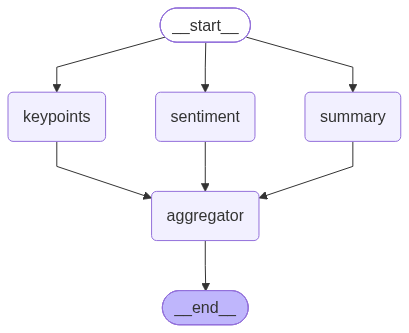

Document analyzer compiled successfully.


In [19]:
# === Build the Document Analyzer Graph ===

analysis_workflow = StateGraph(AnalysisState)

# Add nodes
analysis_workflow.add_node("summary", summary_node)
analysis_workflow.add_node("keypoints", keypoints_node)
analysis_workflow.add_node("sentiment", sentiment_node)
analysis_workflow.add_node("aggregator", analysis_aggregator_node)

# Fan-out: Add edges from START to each parallel analysis node
analysis_workflow.add_edge(START, "summary")
analysis_workflow.add_edge(START, "keypoints")
analysis_workflow.add_edge(START, "sentiment")

# Fan-in: All analysis nodes converge on the aggregator
analysis_workflow.add_edge("summary", "aggregator")
analysis_workflow.add_edge("keypoints", "aggregator")
analysis_workflow.add_edge("sentiment", "aggregator")

# Aggregator leads to END
analysis_workflow.add_edge("aggregator", END)

# Compile
document_analyzer = analysis_workflow.compile()

display(Image(document_analyzer.get_graph().draw_mermaid_png()))
print("Document analyzer compiled successfully.")

<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
<pre>
analysis_workflow.add_edge(START, "summary")
analysis_workflow.add_edge(START, "keypoints")
analysis_workflow.add_edge(START, "sentiment")
</pre>
</p>

</details>

### Test Your Parallel Document Analyzer

Run the cells below to test with the same two documents:
1. **Document A**: Product announcement (positive sentiment)
2. **Document B**: Customer complaint (negative sentiment)

#### Run the Following Cell

In [20]:
# Test Document A: Product Announcement
lg_doc_a = """We are thrilled to announce the launch of our new product line, the EcoSmart Series!
After two years of development, we've created a range of sustainable home products that reduce
energy consumption by up to 40%. Early customer feedback has been overwhelmingly positive,
with pre-orders exceeding our initial projections by 200%. We're expanding our manufacturing
capacity to meet demand and planning international distribution for Q3."""

display(Markdown("# Test Document A: Product Announcement\n\n**Document:**\n> " + lg_doc_a.replace('\n', ' ')))

lg_result_a = document_analyzer.invoke({"document": lg_doc_a})

display(Markdown(lg_result_a["combined_analysis"]))

# Test Document A: Product Announcement

**Document:**
> We are thrilled to announce the launch of our new product line, the EcoSmart Series! After two years of development, we've created a range of sustainable home products that reduce energy consumption by up to 40%. Early customer feedback has been overwhelmingly positive, with pre-orders exceeding our initial projections by 200%. We're expanding our manufacturing capacity to meet demand and planning international distribution for Q3.

# Document Analysis

---

## Summary

The document announces the launch of the EcoSmart Series, a new line of sustainable home products designed to significantly reduce energy consumption. Due to strong early demand and positive feedback, the company is increasing manufacturing and preparing for international distribution.

---

## Key Points

- The company is launching a new product line called the EcoSmart Series, focused on sustainable home products.
- The products reduce energy consumption by up to 40%.
- Pre-orders have exceeded initial projections by 200%, with strong positive customer feedback.
- The company is expanding manufacturing capacity to meet high demand.
- International distribution is planned for Q3.

---

## Sentiment

POSITIVE: The document announces achievements (launch of a new product line), reports good news (positive feedback, high pre-orders, expansion plans), and uses optimistic language throughout.


#### Run the Following Cell

In [21]:
# Test Document B: Customer Complaint
lg_doc_b = """I am extremely disappointed with my recent purchase. The product arrived three weeks
late, and when it finally came, it was damaged. I contacted customer service five times over
the past month, but each time I was put on hold for over an hour and then disconnected.
The replacement they finally sent was the wrong model. I have been a loyal customer for
ten years, but this experience has made me reconsider my relationship with your company."""

display(Markdown("# Test Document B: Customer Complaint\n\n**Document:**\n> " + lg_doc_b.replace('\n', ' ')))

lg_result_b = document_analyzer.invoke({"document": lg_doc_b})

display(Markdown(lg_result_b["combined_analysis"]))

# Test Document B: Customer Complaint

**Document:**
> I am extremely disappointed with my recent purchase. The product arrived three weeks late, and when it finally came, it was damaged. I contacted customer service five times over the past month, but each time I was put on hold for over an hour and then disconnected. The replacement they finally sent was the wrong model. I have been a loyal customer for ten years, but this experience has made me reconsider my relationship with your company.

# Document Analysis

---

## Summary

The document is a complaint from a longtime customer expressing frustration over a late and damaged product delivery, poor customer service, and receiving an incorrect replacement. The main purpose is to communicate dissatisfaction and signal that these issues are causing the customer to reconsider their loyalty to the company.

---

## Key Points

- The product arrived three weeks late and was damaged.
- Customer service was repeatedly unhelpful, with long hold times and disconnections over five separate contacts.
- The replacement product sent was the wrong model.
- The customer, a loyal customer for ten years, is reconsidering their relationship with the company due to this experience.

---

## Sentiment

NEGATIVE: The document expresses strong dissatisfaction with a purchase, citing late delivery, product damage, poor customer service, and an incorrect replacement, all of which are complaints and concerns.


---

## Reflection: Parallelization

You've now implemented the **parallelization** pattern using two different frameworks. Take a moment to reflect on what you've learned.

### The Power of Independence

Parallelization works because tasks are independent. The content generator doesn't need to wait for guardrails before it can write. The FDA ethics check doesn't depend on the product status check. When you identify independent tasks, you unlock the ability to run them simultaneously.

This is a design decision you make as the architect. Sometimes tasks that seem sequential can be restructured as parallel. Instead of "check ethics, then check product, then generate content," you might realize all three operations can happen simultaneously on the same input.

### Fan-Out and Fan-In

The core structure of parallelization is:
1. **Fan-out**: Split work into parallel branches
2. **Process**: Each branch works independently
3. **Fan-in**: Combine results from all branches

In the Agents SDK, you express this with `asyncio.gather()`. In LangGraph, you express it with graph edges. The pattern is the same; only the syntax differs.

### Latency vs. Throughput

Parallelization primarily improves **latency** (how long one request takes). If you have three tasks that take 3, 2, and 2 seconds, parallel execution takes 3 seconds (the slowest) instead of 7 seconds (sequential). That's more than a 2x improvement in response time.

It also enables **throughput** improvements when processing large datasets. If you need to analyze 1000 documents, you can process them in batches of 10 or 100 in parallel, dramatically reducing total processing time.

### When Should You Reach for Parallelization?

Parallelization shines when:
- Tasks are genuinely independent
- Latency matters (user-facing applications)
- You're processing large amounts of data that can be chunked
- You want multiple perspectives on the same input, like our document analyzer exercise

It's less ideal when:
- Tasks have dependencies (output of one feeds into another)
- You're rate-limited by an API (parallel calls might hit limits faster)
- The overhead of coordination exceeds the time saved

### Looking Ahead

So far, you've seen fixed workflows: Prompt chaining follows a set sequence, routing picks one fixed path, and parallelization runs fixed branches. But what if the workflow itself needs to be dynamic? What if an orchestrator needs to decide what steps to take based on the situation?

That's where **orchestrator workflows** come in, and it's what you'll explore in the next activity.